In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = pd.read_csv("../data/X_clean.csv")
Y = pd.read_csv("../data/Y_clean.csv").values.ravel()

# Run your train_test_split to rebuild the arrays your tuned model needs
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

# Re-instantiate your tuned model so K-Means can pull probabilities from it
rf_tuned = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_tuned.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

### Customer Segmentation

In [4]:
y_prob1=rf_tuned.predict_proba(X)

In [5]:
churn_probability=y_prob1[:,1]

In [6]:
segmentation_data=pd.DataFrame({
    'Tenure Months':X['Tenure Months'],
    'Monthly Charges':X['Monthly Charges'],
    'Total Charges':X['Total Charges'],
    'Churn Probability':churn_probability})
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


### Implementation of K-Means

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

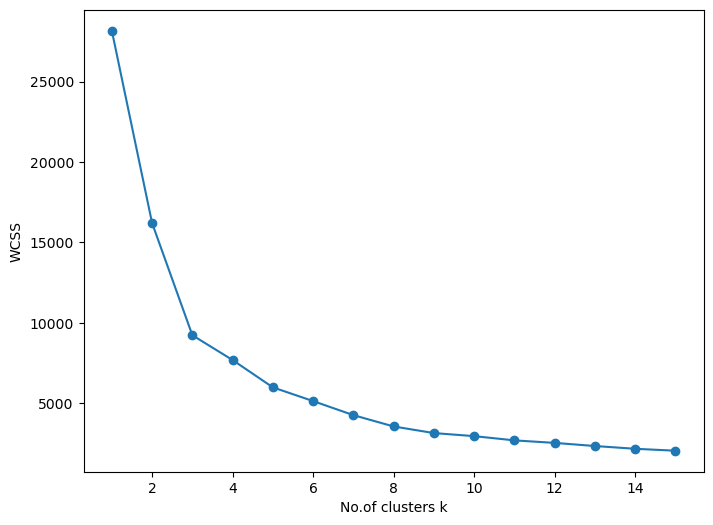

In [9]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
    plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("No.of clusters k")
plt.ylabel("WCSS")
plt.show()

#### K-Means WCSS Elbow Curve
**What the Plot Shows**: The Within-Cluster Sum of Squares (WCSS) drops sharply from K=1 to K=3, and the rate of decrease noticeably levels out (forms an "elbow") right at K=3.

**Mathematical Selection**: This statistical transition establishes that splitting our customer data into exactly 3 distinct clusters yields optimal geometric grouping for our business segmentation.

In [10]:
kmeans=KMeans(n_clusters=3,random_state=42)

In [11]:
clusters=kmeans.fit_predict(scaled_data)

In [12]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


In [13]:
segmentation_data['Cluster']=clusters

In [14]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.676963,1
1,2,70.70,151.65,0.796013,1
2,8,99.65,820.50,0.805827,1
3,28,104.80,3046.05,0.563031,1
4,49,103.70,5036.30,0.517474,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0
7039,24,84.80,1990.50,0.082095,0
7040,72,103.20,7362.90,0.049001,2
7041,11,29.60,346.45,0.302367,0


In [15]:
cluster_summary=segmentation_data.groupby('Cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,32.051471,32.845761,1047.702141,0.120599
1,10.957752,71.961298,884.069671,0.691383
2,58.398884,90.430986,5278.001674,0.230647


In [16]:
cluster_names={
    0:'Budget Loyal Customers',
    1:'High Risk New Customers',
    2:'Loyal Premium Customers',
}

In [17]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.676963,1,High Risk New Customers
1,2,70.70,151.65,0.796013,1,High Risk New Customers
2,8,99.65,820.50,0.805827,1,High Risk New Customers
3,28,104.80,3046.05,0.563031,1,High Risk New Customers
4,49,103.70,5036.30,0.517474,2,Loyal Premium Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0,Budget Loyal Customers
7039,24,84.80,1990.50,0.082095,0,Budget Loyal Customers
7040,72,103.20,7362.90,0.049001,2,Loyal Premium Customers
7041,11,29.60,346.45,0.302367,0,Budget Loyal Customers


<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

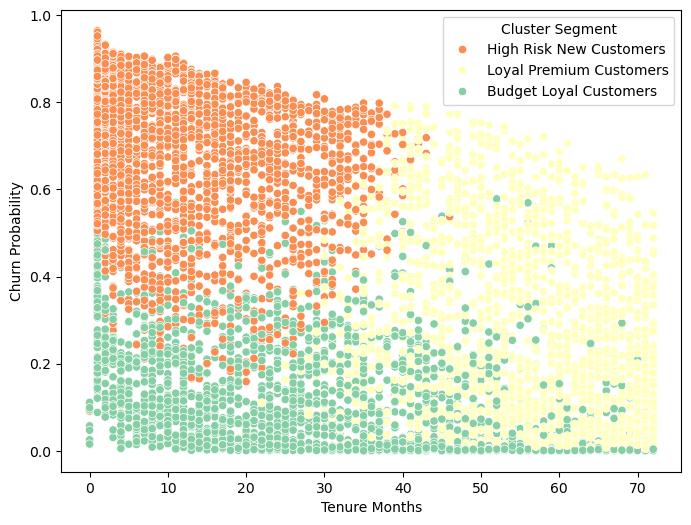

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')

#### Tenure vs Model Churn Probability
**What the Plot Shows**: The graph clearly separates our customers by risk. 'High Risk New Customers' occupy the top-left area (low tenure, maximum churn risk), while our veteran groups stretch safely across the bottom.

**Business Takeaway**: Churn risk is concentrated in the early months. This reinforces the need for an aggressive onboarding strategy to guide new users through their high-risk initial phase.

<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

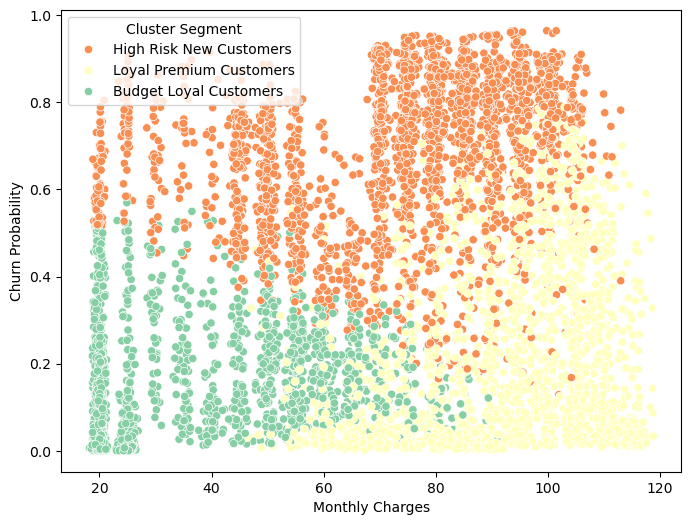

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')

#### Monthly Charges vs Model Churn Probability
**What the Plot Shows**: This chart highlights a striking financial boundary. Customers paying over $70 per month face an aggressive spike in churn probability, separating our premium revenue tiers into distinct high-risk and low-risk groups.

**Business Takeaway**: Higher bills act as a churn catalyst. The business should proactively offer custom value add-ons or loyalty bundles to accounts crossing the $70 threshold to justify their premium pricing.

<Axes: xlabel='Total Charges', ylabel='Churn Probability'>

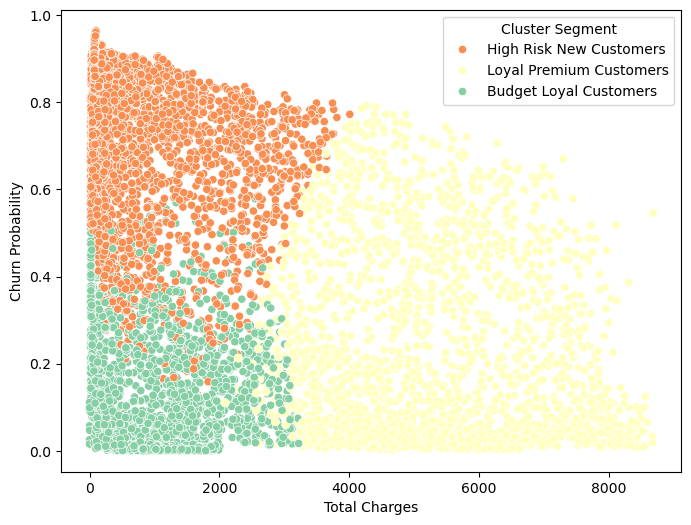

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total Charges',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')

#### Total Charges vs Model Churn Probability
**What the Plot Shows**: High lifetime value ('Total Charges') aligns directly with a near-zero churn probability. The risk is concentrated almost entirely among accounts with low total lifetime spend.

**Business Takeaway**: The long-term customer base is incredibly secure. Marketing budgets shouldn't be wasted on retaining deep legacy accounts; instead, those resources should be redirected toward converting new, low-spend accounts into long-term users.